Name: qizhou lin  
Task: Image Classification with an MLP on Fashion-MNIST  
Key Insights:  
- Learned to load the FashionMNIST dataset using torchvision.datasets  
- Used an MLP model for multi-class image classification  
- Flattened image inputs correctly for the MLP  
- Applied CrossEntropyLoss and Adam optimizer in training  




In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])


In [ ]:
train_dataset = datasets.FashionMNIST(root='.', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='.', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


100%|██████████| 26.4M/26.4M [00:01<00:00, 20.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 346kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.23MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.0MB/s]


In [ ]:
class ImageMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.model(x)

model = ImageMLP()


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
for epoch in range(10):
    model.train()
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/10, Loss: {loss.item():.4f}")


Epoch 1/10, Loss: 0.3926
Epoch 2/10, Loss: 0.1558
Epoch 3/10, Loss: 0.5809
Epoch 4/10, Loss: 0.3695
Epoch 5/10, Loss: 0.1500
Epoch 6/10, Loss: 0.3544
Epoch 7/10, Loss: 0.4076
Epoch 8/10, Loss: 0.2549
Epoch 9/10, Loss: 0.1891
Epoch 10/10, Loss: 0.0682


In [ ]:
correct = 0
total = 0
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Test Accuracy: 88.32%


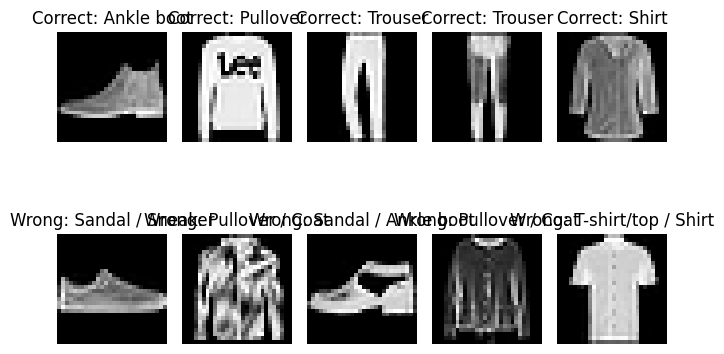

In [ ]:
import matplotlib.pyplot as plt

classes = train_dataset.classes
wrong = []
correct = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        for i in range(len(labels)):
            if predicted[i] == labels[i] and len(correct) < 5:
                correct.append((images[i], predicted[i]))
            elif predicted[i] != labels[i] and len(wrong) < 5:
                wrong.append((images[i], predicted[i], labels[i]))
        if len(correct) >= 5 and len(wrong) >= 5:
            break

for i, (img, pred) in enumerate(correct):
    plt.subplot(2, 5, i + 1)
    plt.imshow(img.view(28, 28), cmap='gray')
    plt.title(f"Correct: {classes[pred]}")
    plt.axis('off')

for i, (img, pred, label) in enumerate(wrong):
    plt.subplot(2, 5, i + 6)
    plt.imshow(img.view(28, 28), cmap='gray')
    plt.title(f"Wrong: {classes[pred]} / {classes[label]}")
    plt.axis('off')

plt.tight_layout()
plt.show()
